**Paquetes y librerías**

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math as mt
import plotly.express as px
import plotly.graph_objects as go
from scipy.integrate import quad, dblquad
import sympy as sp
import nbformat


#data = np.random.normal(0, 1, 100000)
#sns.histplot(data, kde=True)
#plt.show()

## **Punto 1**

Una barra de 12 pulgadas, sujeta en ambos extremos, se someterá a una tensión creciente hasta que se rompa. Sea $Y$ la distancia desde el borde:

$$
f_Y(y)=
\begin{cases}
\frac{1}{24}\,y\left(1-\frac{y}{12}\right), & 0 \le y \le 12,\\[4pt]
0, & \text{en otro caso}.
\end{cases}
$$

**Gráfica de la f.d.p.**

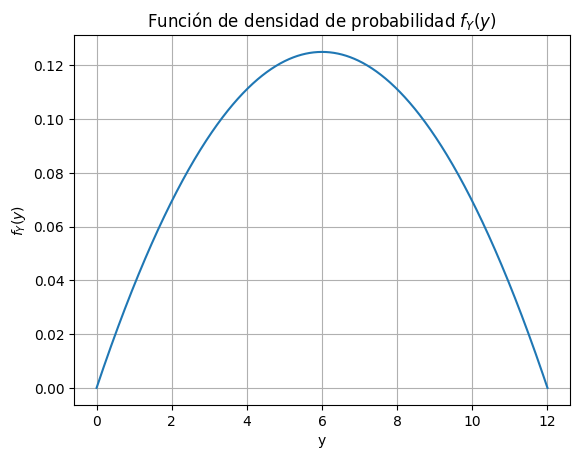

In [2]:
fY = lambda y : (y*(1 - y/12))/24
y = np.linspace(0, 12, 1000)

plt.plot(y, fY(y))
plt.xlabel('y')
plt.ylabel(r'$f_Y(y)$')
plt.title(r'Función de densidad de probabilidad $f_Y(y)$')
plt.grid()
plt.show()

**A partir de esta f.d.p., Calcule:**

### **a.** 
La función de distribución acumulada (f.d.a.) de $Y$ y su representación gráfica.

In [3]:
FY = lambda y : (y**2/48) - (y**3/864)

y = np.linspace(0, 12, 1000)

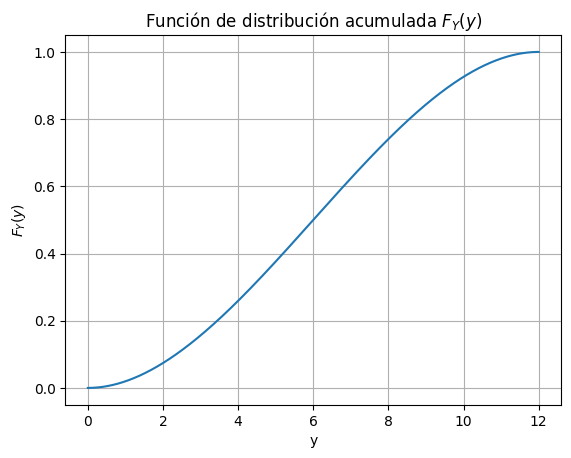

In [4]:
plt.plot(y, FY(y))
plt.xlabel('y')
plt.ylabel(r'$F_Y(y)$')
plt.title(r'Función de distribución acumulada $F_Y(y)$')
plt.grid()
plt.show()

**b.** $P(Y ≤ 4)$, $P(Y > 6)$ y $P(4 ≤ Y ≤ 6)$.

In [5]:
# Es trivial al usar la función de distribución acumulada FY(y)
P_Y_le_4 = FY(4)
P_Y_Mo_6 = 1 - FY(6)
P_Y_4_6 = FY(6) - FY(4)


print(f'P(Y <= 4) = {P_Y_le_4:.4f}')
print(f'P(Y > 6) = {P_Y_Mo_6:.4f}')
print(f'P(4 < Y <= 6) = {P_Y_4_6:.4f}')


P(Y <= 4) = 0.2593
P(Y > 6) = 0.5000
P(4 < Y <= 6) = 0.2407


**c.** Los valores esperados $E(Y)$, $E(Y^2)$ y la varianza $V(Y)$.

In [6]:
# Calculemos E(Y)
E_Y, err = quad(lambda y: y * fY(y), 0, 12)
print(f'E(Y) = {E_Y:.4f} +- {err:.4e}')

E(Y) = 6.0000 +- 6.6613e-14


In [7]:
# Calculemos E(Y**2)
E_Y2, err = quad(lambda y: y**2 * fY(y), 0, 12)
print(f'E(Y**2) = {E_Y2:.4f} +- {err:.4e}')


E(Y**2) = 43.2000 +- 4.7962e-13


In [8]:
np.sqrt(E_Y2)

np.float64(6.572670690061993)

In [9]:
# Calculo de Var(Y)
Var_Y = E_Y2 - E_Y**2
err_Var_Y = np.sqrt(err**2 + err**2)  # Error propagado

print(f'Var(Y) = {Var_Y:.4f} +- {err_Var_Y:.4e}')

Var(Y) = 7.2000 +- 6.7828e-13


**d.** La probabilidad de que el punto de ruptura ocurra a más de 2 pulgadas del valor esperado.

In [10]:
X_1 = E_Y + 2

P_Y_mo_E_Y2 = 1 - FY(X_1)

print(f'P(Y > E(Y) + 2) = {P_Y_mo_E_Y2:.4f}')

P(Y > E(Y) + 2) = 0.2593


**e.** La longitud esperada del segmento más corto de la barra al romperse.

In [11]:
# se define la funcion de longitud mas pequeña de la barra al romperse
def l_min(x):
    if 0 <= x <= 6:
        return x
    elif 6 < x <= 12:
        return 12 - x
    else:
        return 0


In [12]:
# Se encuentra el valor esperado de la longitud mas pequeña al romperse la barra
E_L_min, err = quad(lambda x: l_min(x) * fY(x), 0, 12)
print(f'E(L_min) = {E_L_min:.4f} +- {err:.4e}')

E(L_min) = 3.7500 +- 4.1744e-14


## **Punto 2**

**El Problema de la Aguja de Buffon**

Suponga que el piso tiene líneas paralelas igualmente espaciadas a una distancia $l$ entre sí. Una aguja de longitud $a < l$ cae aleatoriamente sobre el piso. Encuentre la probabilidad de que la aguja intersecte una línea.

$$P(0 < Y < \frac{a}{2}cos\theta, 0 < \theta < \frac{\pi}{2}) = \int_0^{\pi/2} \int_0^{a/2 \cos{\theta}} \frac{4}{\pi\, L} dy d\theta$$

In [13]:
import numpy as np
from scipy.integrate import quad
import sympy as sp

# Constantes (valores de ejemplo para evaluación numérica)
a_val = 1.2
l_val = 3.0

# -------- Método numérico con quad (anidado) --------
def inner(theta, a, l):
    integrando = lambda y: 4.0 / (np.pi * l)
    y_superior = (a / 2.0) * np.cos(theta)
    val, _ = quad(integrando, 0.0, y_superior)
    return val

I_num, err_num = quad(lambda th: inner(th, a_val, l_val), 0.0, np.pi / 2)
print("P(0 < X < a/2cos(theta), 0 < theta < pi/2) =", I_num, "+/-", err_num)



P(0 < X < a/2cos(theta), 0 < theta < pi/2) = 0.2546479089470326 +/- 2.82715971685646e-15


In [14]:
# -------- Solución simbólica con sympy para cualquier a y l --------
a, l, theta, y = sp.symbols('a l theta y', positive=True)

I_sym = sp.integrate(
    sp.integrate(4/(sp.pi*l), (y, 0, (a/2)*sp.cos(theta))),
    (theta, 0, sp.pi/2)
)
I_sym_simplified = sp.simplify(I_sym)


print("P(0 < X < a/2cos(theta), 0 < theta < pi/2) =", I_sym_simplified)   # 2*a/(pi*l)

# Opcional: evaluar el resultado simbólico con las mismas constantes numéricas
I_sym_num = I_sym_simplified.subs({a: a_val, l: l_val}).evalf()
print("P(0 < X < a/2cos(theta), 0 < theta < pi/2) (valor numérico) =", I_sym_num)

P(0 < X < a/2cos(theta), 0 < theta < pi/2) = 2*a/(pi*l)
P(0 < X < a/2cos(theta), 0 < theta < pi/2) (valor numérico) = 0.254647908947033


**forma de estimar el número $\pi$ apartir de este resultado**

In [15]:
# definamos nuevos parametrs de a y l para evaluar el resultado simbólico
a_val_2 = 2.0
l_val_2 = 4.0

# generamos numeros aleatrios de la variable 'X' y 'theta' para simular el experiment0
num_samples = 10000000
X_samples = np.random.uniform(0, l_val_2/2, num_samples)
theta_samples = np.random.uniform(0, np.pi/2, num_samples)

# evaluamos la condición X < a/2cos(theta) para cada par (X, theta)
condition = X_samples < (a_val_2 / 2) * np.cos(theta_samples)

# calculamos la proporción de muestras que cumplen la condición
trues =[]
for i in range(len(condition)):
    if condition[i] == True:
        trues.append(condition[i])

trues = np.array(trues)

tam_trues = len(trues)
tam_pob = len(condition)
print(f'Proporción de trues: {tam_trues/tam_pob:.4f}')


print("P(0 < X < a/2cos(theta), 0 < theta < pi/2) (simulación) =", tam_trues/tam_pob)

Proporción de trues: 0.3181
P(0 < X < a/2cos(theta), 0 < theta < pi/2) (simulación) = 0.3181425


**Cálculo de $\pi$ mediante la relacion:**

$$
P\left(0 < X < \frac{a}{2}cos\theta, 0 < \theta < \frac{\pi}{2}\right) = \frac{2 a}{\pi L} \implies \pi = \frac{2a}{P L }
$$

In [16]:
# Calculemos pi
P_val_2 = tam_trues/tam_pob

pi_estimado = 2*a_val_2/(P_val_2*l_val_2)

print('estimación de pi mediante el experimento de la aguja de Buffon:', pi_estimado)



estimación de pi mediante el experimento de la aguja de Buffon: 3.1432455582011207


## **Punto 3**

**Lluvia de estrellas.**

Se cuenta la cantidad de meteoros observados en cierta lluvia de estrellas durante una época del año. El número de meteoros contados por día sigue una distribución de Poisson con parámetro 50.

**a)** Encuentre una aproximación a la probabilidad de que, en un día particular durante el evento, se observen entre 35 y 70 meteoros.

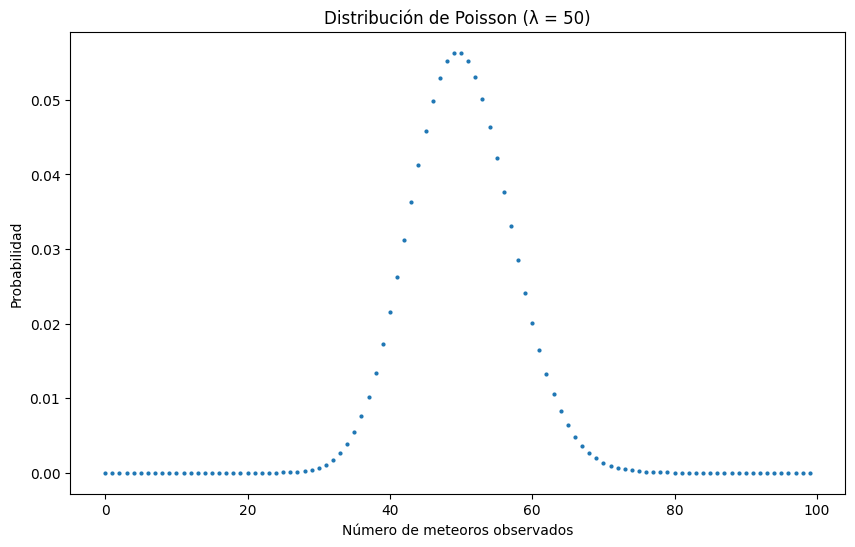

In [17]:
from scipy.special import gammaln

d_poi = lambda x, lam: np.exp(x * np.log(lam) - lam - gammaln(x + 1))

parametro = 50 # valor esperado de la distribución de Poisson

# Grafica de la distribucion de poisson
plt.figure(figsize=(10, 6))
x_poi = np.arange(0, 100)
y_poi = d_poi(x_poi, parametro)
plt.plot(x_poi, y_poi, 'o', markersize=2)
plt.xlabel('Número de meteoros observados')
plt.ylabel('Probabilidad')
plt.title('Distribución de Poisson (λ = 50)')
plt.show()

In [18]:
# como se define 'X' como el número de meteoros observados en un día, entonces 'X' sigue una distribución de Poisson con parámetro lambda = 50

# la probabilidad de que 35<= X <= 70 es la suma de las probabilidades individuales para cada valor de X entre 35 y 70
probabilidad = sum(d_poi(x, parametro) for x in range(35, 71))

print(f'P(35 <= X <= 70) = {probabilidad:.4f}')

P(35 <= X <= 70) = 0.9862


**b)** Calcule una aproximación a la probabilidad de que el número total de meteoros observados durante 5 días del evento esté entre 225 y 275.

In [19]:
parametro_nuevo = 5*parametro

probabilidad_5dias = sum(d_poi(x, parametro_nuevo) for x in range(225, 275))

print(f'P(225 <= X <= 275) = {probabilidad_5dias:.4f}')

P(225 <= X <= 275) = 0.8862


**c)** Con ayuda de un computador, calcule los valores exactos de las probabilidades en a) y b).

## **Punto 4**

**Calíbreme el aire.**

Cada neumático delantero de un tipo particular de vehículo debe inflarse con una presión de $26\ \text{psi}$. Suponga que la presión del aire dentro de cada rueda es una variable aleatoria: $X$ para la rueda derecha y $Y$ para la izquierda, con función de densidad conjunta

$$
f_{X,Y}(x,y)=
\begin{cases}
K(x^2+y^2), & 20 \le x \le 30,\ 20 \le y \le 30,\\
0, & \text{en otro caso}.
\end{cases}
$$

### **a**
Cuánto vale $K$?

**Sln**

Para esto, resolvemos simbolicamente la integral de la función de densidad de probabilidad simbolicamente y teniendo en cuenta debe dar $1$, se despeja el parametro $K$.

In [20]:
 # -------- Solución simbólica con sympy para cualquier a y l --------
X, Y, Ksim = sp.symbols('x y K', positive=True)

I_sym = sp.integrate(
    sp.integrate(Ksim*(X**2 + Y**2), (Y, 20, 30)),
    (X, 20, 30)
)

I_sym_simplified = sp.simplify(I_sym)

I_sym_simplified

380000*K/3

In [21]:
K = 3/380000

print(f'Valor de K: {K:.8f}')

Valor de K: 0.00000789


**Gráfica de $f_{X Y}(x,y)$**

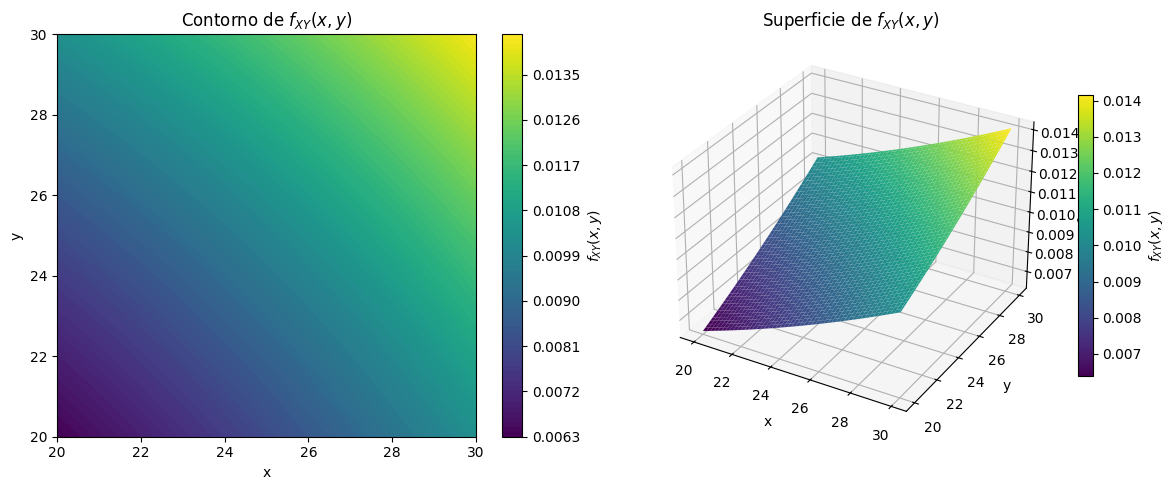

In [22]:
fXY = lambda x, y: K*(x**2 + y**2)
xs = np.linspace(20, 30, 100)
ys = np.linspace(20, 30, 100)
X_s, Y_s = np.meshgrid(xs, ys)
Z_s = fXY(X_s, Y_s)

fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(1, 2, 1)
cont = ax1.contourf(X_s, Y_s, Z_s, levels=80, cmap='viridis')
fig.colorbar(cont, ax=ax1, label=r'$f_{XY}(x, y)$')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title('Contorno de $f_{XY}(x, y)$')

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf = ax2.plot_surface(X_s, Y_s, Z_s, cmap='viridis', edgecolor='none')
fig.colorbar(surf, ax=ax2, shrink=0.7, label=r'$f_{XY}(x, y)$')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel(r'$f_{XY}(x, y)$')
ax2.set_title('Superficie de $f_{XY}(x, y)$')

plt.tight_layout()
plt.show()


In [23]:


# Gráfica 3D interactiva de fXY con mapa de color (Plotly)
fig_plotly = go.Figure(
	data=[
		go.Surface(
			x=xs,
			y=ys,
			z=Z_s,
			colorscale="Viridis",   # puedes cambiar a "Plasma", "Cividis", "Turbo", etc.
			colorbar=dict(title="fXY(x,y)"),
			contours={
				"z": {"show": True, "usecolormap": True, "highlightcolor": "white", "project_z": True}
			},
			hovertemplate="x=%{x:.2f}<br>y=%{y:.2f}<br>fXY=%{z:.2e}<extra></extra>"
		)
	]
)

fig_plotly.update_layout(
	title="Superficie 3D interactiva de fXY(x, y)",
	scene=dict(
		xaxis_title="x (psi)",
		yaxis_title="y (psi)",
		zaxis_title="fXY(x,y)"
	),
	width=900,
	height=700
)

fig_plotly.show(renderer="browser")

### **b**
Cuál es la probabilidad de que ambos neumáticos estén bajos de aire?

In [24]:
# dbemos resolver la integral doble de fXY sobre el cuadrado [20, 26] x [20, 26] para encontrar la probabilidad de que (X, Y) esté en ese cuadrado

def fXY_integrand(y, x):
    return K*(x**2 + y**2) 

integral_result, error = dblquad(fXY_integrand, 20, 26, lambda x: 20, lambda x: 26)

print(f'P((X, Y) en [20, 26] x [20, 26]) = {integral_result:.6f} +- {error:.2e}')

P((X, Y) en [20, 26] x [20, 26]) = 0.302400 +- 3.36e-15


### **c**
Cuál es la probabilidad de que la diferencia en la presión de aire entre las dos llantas sea, a lo sumo, $2\ \text{psi}$?

**Sln**

Queremos encontrar $P(|X-Y| \leq 2)$, para esto hay que encontrar la region correspondiente a este conjuto de pares $(x, y)$ asi: 

$$
P(|X-Y| \leq 2) = \int_{|X-Y| \leq 2} f_{X Y}(x, y) \, dy dx
$$

Haciendo un poco de algebra: 

$$
x-2 \leq y \leq x+2 \quad \wedge \quad 20 \leq x \leq 30
$$

**Gráfica de la región**

In [25]:
xs = np.linspace(20, 30, 100)
ys_up = xs + 2
ys_down = xs - 2

In [26]:
# Mask para la region 

mask1 = ys_up < 30
mask2 = ys_down > 20

xs1 = xs[mask1]
xs2 = xs[mask2]
ys1 = ys_up[mask1]
ys2 = ys_down[mask2]

In [27]:
xs1.shape, ys1.shape, xs2.shape, ys2.shape

((80,), (80,), (80,), (80,))

In [28]:
xs2[:10], xs[:10]

(array([22.02020202, 22.12121212, 22.22222222, 22.32323232, 22.42424242,
        22.52525253, 22.62626263, 22.72727273, 22.82828283, 22.92929293]),
 array([20.        , 20.1010101 , 20.2020202 , 20.3030303 , 20.4040404 ,
        20.50505051, 20.60606061, 20.70707071, 20.80808081, 20.90909091]))

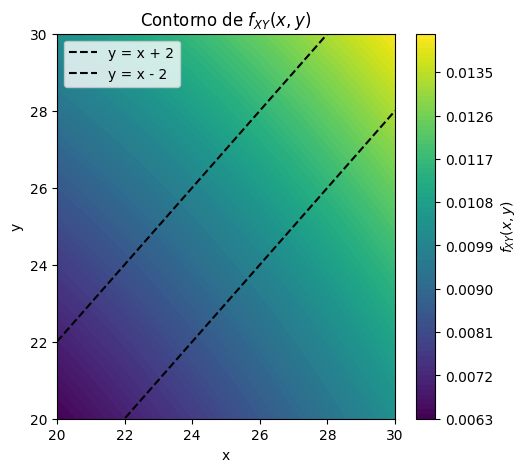

In [29]:
fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(1, 2, 1)
cont = ax1.contourf(X_s, Y_s, Z_s, levels=80, cmap='viridis')
fig.colorbar(cont, ax=ax1, label=r'$f_{XY}(x, y)$')
ax1.plot(xs1, ys1, color='black', linestyle='--', label='y = x + 2')
ax1.plot(xs2, ys2, color='black', linestyle='--', label='y = x - 2')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title('Contorno de $f_{XY}(x, y)$')
ax1.legend()

plt.show()


Graficando la region de interes, podemos observar que esta compuesta de la siguiente forma:
$$
\mathcal{D} \equiv (20 \leq x \leq 22) \times (20 \leq y \leq x+2) \cup (22 \le x \le 28) \times (x-2 \le y \le x+2) \cup (28 \leq x \leq 30) \times (x -2 \leq y \leq 30)
$$

y 

$$
P(|X-Y| \leq 2) = \int_{\mathcal{D}} f_{X Y}(x, y) \, dy dx
$$

In [30]:
# integraremos sobre esta compleja region y luego veremos una forma mas simple de encontrar la probabilidad.

# para la primera region
reg_x11 = 20
reg_x12 = 22

reg_y11 = lambda x: 20
reg_y12 = lambda x: x+2

int_reg_1 = dblquad(fXY_integrand, reg_x11, reg_x12, reg_y11, reg_y12)

# Para la segunda region

reg_x21 = 22
reg_x22 = 28

reg_y21 = lambda x: x-2
reg_y22 = lambda x: x+2

int_reg_2 = dblquad(fXY_integrand, reg_x21, reg_x22, reg_y21, reg_y22)

# Para la tercera region
reg_x31 = 28
reg_x32 = 30

reg_y31 = lambda x: x-2
reg_y32 = lambda x: 30

int_reg_3 = dblquad(fXY_integrand, reg_x31, reg_x32, reg_y31, reg_y32)

print(f'P((X, Y) en region 1) = {int_reg_1[0]:.6f} +- {int_reg_1[1]:.2e}')
print(f'P((X, Y) en region 2) = {int_reg_2[0]:.6f} +- {int_reg_2[1]:.2e}')
print(f'P((X, Y) en region 3) = {int_reg_3[0]:.6f} +- {int_reg_3[1]:.2e}')


P((X, Y) en region 1) = 0.043179 +- 4.79e-16
P((X, Y) en region 2) = 0.238232 +- 2.64e-15
P((X, Y) en region 3) = 0.077916 +- 8.65e-16


In [31]:
# encontremos la probabilidad total

P_total_regions = int_reg_1[0] + int_reg_2[0] + int_reg_3[0]
err_total_regions = np.sqrt(int_reg_1[1]**2 + int_reg_2[1]**2 + int_reg_3[1]**2)

print(f'P((X, Y) en la region delimitada por las lineas y = x + 2 y y = x - 2) = {P_total_regions:.16f} +- {err_total_regions:.2e}')

P((X, Y) en la region delimitada por las lineas y = x + 2 y y = x - 2) = 0.3593263157894737 +- 2.82e-15


### **d**
Determine la distribución marginal de la presión de aire en la llanta derecha.

In [32]:
# Resolveremos simbolicamente para encontrar la fdp marginal de X

X, Y = sp.symbols('x y', positive=True)
fXY_sym = K*(X**2 + Y**2)

fX_sym = sp.integrate(fXY_sym, (Y, 20, 30))
fX_sym_simplified = sp.simplify(fX_sym)

fX_sym

7.89473684210526e-5*x**2 + 0.05

In [33]:
# comprobemos que la integral de fX_sym sobre el rango de X es 1

print('La integral de fX_sym sobre el rango de X es:', sp.integrate(fX_sym_simplified, (X, 20, 30)))


La integral de fX_sym sobre el rango de X es: 1.00000000000000


### **e**
Son $X$ y $Y$ variables independientes?

Para comprobar esto, hacemos uso de el hecho de que $X,Y \text{  independientes } \implies \text{Cov}(x,y) = 0$. A continuación se hace el calculo del valor esperado de $X, Y$.

In [34]:
# Calculemos los valores esperados de X e Y usando las dblquad
E_X, err_E_X = dblquad(lambda x, y: x * fXY_sym.subs({X: x, Y: y}).evalf(), 20, 30, 20, 30)

E_Y, err_E_Y = dblquad(lambda x, y: y * fXY_sym.subs({X: x, Y: y}).evalf(), 20, 30, 20, 30)

print(f'E(X) = {E_X:.4f} +- {err_E_X:.4e}')
print(f'E(Y) = {E_Y:.4f} +- {err_E_Y:.4e}')

E(X) = 25.3289 +- 2.8121e-13
E(Y) = 25.3289 +- 2.8121e-13


Cálculo de $\text{Cov}(x,y)$

In [35]:
# Con los valores esperados de X e Y, podemos calcular la covarianza
Cov_XY, err_Cov_XY = dblquad(lambda x, y: (x - E_X) * (y - E_Y) * fXY_sym.subs({X: x, Y: y}).evalf(), 20, 30, 20, 30)

print(f'Cov(X, Y) = {Cov_XY:.4f} +- {err_Cov_XY:.4e}')

Cov(X, Y) = -0.1082 +- 1.5578e-14


**R/=** Vemos que $\text{Cov} \neq 0$, por lo tanto $X, Y$ no son variables independientes.

### **f**
Determine la f.d.p. condicional de $Y$ dado que $X=x$, $f_{(Y\mid X)}(y\mid x)$, y la f.d.p. condicional de $X$ dado que $Y=y$, $f_{(X\mid Y)}(x\mid y)$.

**Sln**

Sabiendo que: 

$$
f_{x|y}(x|y) = \frac{f(x,y)}{f_y(y)}
$$

In [36]:
# Nos falta encontrar fY, asi que hagamoslo primero mediante sp.integrate
fY_sym = sp.integrate(fXY_sym, (X, 20, 30))
fY_sym_simplified = sp.simplify(fY_sym) 
fY_sym_simplified

7.89473684210526e-5*y**2 + 0.05

In [37]:
# Con fX y fY ya podemos calcular simbolicamente las fdps condicionales

# para f(X|Y):
fX_Y = fXY_sym / fY_sym
fX_Y_simplified = sp.simplify(fX_Y)

fX_Y_simplified


7.89473684210526e-6*(x**2 + y**2)/(7.89473684210526e-5*y**2 + 0.05)

In [38]:
# para f(Y|X):
fY_X = fXY_sym / fX_sym
fY_X_simplified = sp.simplify(fY_X)

fY_X_simplified

7.89473684210526e-6*(x**2 + y**2)/(7.89473684210526e-5*x**2 + 0.05)

### **g**
Si la presión de la llanta derecha es de $22\ \text{psi}$, cuál es la probabilidad de que la presión en la izquierda sea de al menos $25\ \text{psi}$? Compare este resultado con $P(Y \ge 25)$.

**Sln**

para esto, debemos calcular: 

$$
P = \int_{20}^{25} f_{(Y|X)}(22,y) dy
$$

In [39]:
# Calculemos la probabilidad de que X esté entre 22 y 28 usando la fdp condicional lambdificdada

fY_X_func = sp.lambdify((X, Y), fY_X_simplified, 'numpy')
X_val = 22

P_condicional = quad(lambda y: fY_X_func(X_val, y), 20, 25)

print(f'P(20 < Y < 25 | X = 22 Psi) = {P_condicional[0]:.15f} +- {P_condicional[1]:.2e}')

P(20 < Y < 25 | X = 22 Psi) = 0.444063245823389 +- 4.93e-15


In [40]:
#calculemos la probabilidad de que Y esté entre 20 y 25 usando la fdp marginal de Y

fY_func = sp.lambdify(Y, fY_sym_simplified, 'numpy')

P_marginal = quad(fY_func, 20, 25)

print(f'P(20 < Y < 25) = {P_marginal[0]:.15f} +- {P_marginal[1]:.2e}')

P(20 < Y < 25) = 0.450657894736842 +- 5.00e-15


**R/=** Vemos que $P(Y \leq 25 | X = 22 \text{ Psi}) \neq P(Y \leq 25)$ lo que vuelve a confirmar que las variables $X, Y$ no son independientes.

### **h**
Si la presión de la llanta derecha es de $22\ \text{psi}$, cuál es la presión esperada en la izquierda y cuál es la desviación estándar de la presión en esa llanta?

**Sln**

Para esto, se debe calcular $E\left[ f_{(Y|X)}(Y| X= 22 \text{ Psi}) \right]$, es decir:

In [41]:
# hagamoslo usando la fdp condicional de Y dado X y la fdp original de X,Y
f_yX = lambda y: y * fY_X_func(X_val, y) 

E_condicional22 = quad(lambda y:  f_yX(y), 20, 30)
print(f'E(Y | X = 22 Psi) = {E_condicional22[0]:.4f} +- {E_condicional22[1]:.2e}')

E(Y | X = 22 Psi) = 25.3729 +- 2.82e-13


In [42]:
# Veamos el valor de la desviación estandar de Y dado X = 22 Psi

Var_condicional22 = quad(lambda y: (y - E_condicional22[0])**2 * fY_X_func(X_val, y), 20, 30)
print(f'Var(Y | X = 22 Psi) = {Var_condicional22[0]:.4f} +- {Var_condicional22[1]:.2e}')
print(f'Std(Y | X = 22 Psi) = {np.sqrt(Var_condicional22[0]):.4f} +- {np.sqrt(Var_condicional22[1]):.2e}')

Var(Y | X = 22 Psi) = 8.2440 +- 9.15e-14
Std(Y | X = 22 Psi) = 2.8712 +- 3.03e-07


## **Punto 5**

**Ajustes de matrícula**

El tiempo empleado por un estudiante de cierta universidad, seleccionado de forma aleatoria, en realizar ajustes de matrícula sigue una distribución normal.

**Datos:**
- Media: $\mu = 10$ minutos
- Desviación estándar: $\sigma = 2$ minutos
- Tamaño de muestra día $1$: $n_1 = 5$ estudiantes
- Tamaño de muestra día $2$: $n_2 = 6$ estudiantes

**Pregunta:**
¿Cuál es la probabilidad de que el promedio muestral del tiempo empleado, considerando ambos días, sea como máximo de 11 minutos?

In [43]:
# realizamos una función de distribucion normal

N = lambda x, mu, sigma: (1/(sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu)/sigma)**2)

# Datos que tenemos
mu = 10 # minutos
sigma = 2 # minutos
n1 = 5 
n2 = 6 

**gráfica de la fdp del tiempo empleado de los estudiantes**

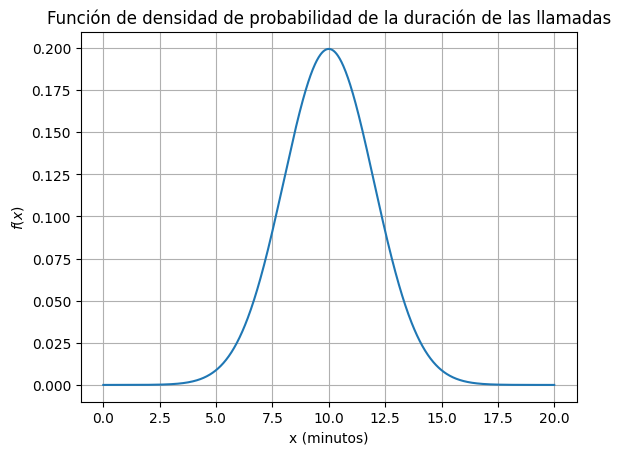

In [44]:
x = np.linspace(0, 20, 1000)

plt.Figure(figsize=(10, 6))
plt.plot(x, N(x, mu, sigma))
plt.xlabel('x (minutos)')
plt.ylabel(r'$f(x)$')
plt.title(r'Función de densidad de probabilidad de la duración de las llamadas')
plt.grid()
plt.show()

In [45]:
# sin embargo, el promedio de las muestras n1, y n2 tambien siguen una distribucion normal a su vez, con: 

sigma_n1 = sigma / np.sqrt(n1)
sigma_n2 = sigma / np.sqrt(n2)

mu_n1 = mu
mu_n2 = mu

# Calculemos los correspondientes valores para las probabilidades propuestas

p1_11 = quad(lambda x: N(x, mu_n1, sigma_n1), -np.inf, 11)[0]
p2_11 = quad(lambda x: N(x, mu_n2, sigma_n2), -np.inf, 11)[0]

print(f'P(X_promedio_dia_1 <= 11) = {p1_11:.4f}')
print(f'P(X_promedio_dia_2 <= 11) = {p2_11:.4f}')


P(X_promedio_dia_1 <= 11) = 0.8682
P(X_promedio_dia_2 <= 11) = 0.8897


## **Punto 6**

**Modulo de Young**

El modulo de Young de una lamina de cierta aleacion de aluminio se modela con una distribucion normal.


**Datos:**
- Media: $\mu = 70$ GPa
- Desviacion estandar: $\sigma = 1.6$ GPa

In [46]:
# Datos generales

media_young = 70
desviacion_young = 1.6

### **a**
Si $\bar{X}$ es la media muestral del modulo de Young para una muestra de $n = 16$ laminas, donde esta centrada la distribucion de $\bar{X}$ y cual es su desviacion estandar?

In [47]:
# USando el TLC:
mu_Xbar16 = media_young
sigma_Xbar16 = desviacion_young / np.sqrt(16)

print(f'La media de X_barra con n=16 es: {mu_Xbar16:.4f}')
print(f'La desviación estándar de X_barra con n=16 es: {sigma_Xbar16:.4f}')

La media de X_barra con n=16 es: 70.0000
La desviación estándar de X_barra con n=16 es: 0.4000


### **b**
Responda las preguntas en (a) para una muestra de $n = 64$ laminas.

In [48]:
# USando el TLC para n=64

mu_Xbar64 = media_young
sigma_Xbar64 = desviacion_young / np.sqrt(64)

print(f'La media de X_barra con n=64 es: {mu_Xbar64:.4f}')
print(f'La desviación estándar de X_barra con n=64 es: {sigma_Xbar64:.4f}')

La media de X_barra con n=64 es: 70.0000
La desviación estándar de X_barra con n=64 es: 0.2000


### **c**
En cual de las dos muestras anteriores es mas probable que $\bar{X}$ este a $1 \text{ GPa}$ de $70 \text{ GPa}$?

In [49]:
# para esto, se calcula la probabilidad de que 69 < X_promedio < 71

p_Xbar16 = quad(lambda x: N(x, mu_Xbar16, sigma_Xbar16), 69, 70)[0]
p_Xbar64 = quad(lambda x: N(x, mu_Xbar64, sigma_Xbar64), 69, 70)[0]

print(f'P(69 < X_promedio_dia_1 < 71) = {p_Xbar16:.15f}')
print(f'P(69 < X_promedio_dia_2 < 71) = {p_Xbar64:.15f}')

print('Es mas probable que X_promedio este a 1 Gpa de mu con la muestra de 64 laminas')

P(69 < X_promedio_dia_1 < 71) = 0.493790334674224
P(69 < X_promedio_dia_2 < 71) = 0.499999713348428
Es mas probable que X_promedio este a 1 Gpa de mu con la muestra de 64 laminas


### **d**
Suponga que la distribucion es normal. Calcule la probabilidad de que $\bar{X}$ este entre 69 GPa y 71 GPa, con una muestra de $n = 16$ laminas.

### **e**
Con esto, que tan probable es que $\bar{X}$ exceda los 71 GPa si $n = 25$?

In [50]:
# sea n3 = 25
n3 = 25 

sigma_Xbar25 = desviacion_young / np.sqrt(n3)
mu_Xbar25 = media_young

P25 = quad(lambda x: N(x, mu_Xbar25, sigma_Xbar25), -np.inf, 71)[0]

P25prime = 1 - P25

print(f'P(X_promedio > 71) con n=25 = {P25prime:.15f}')
print('Bastante baja la probabilidad')


P(X_promedio > 71) con n=25 = 0.000889025299110
Bastante baja la probabilidad


## **Punto 7**

**Función de densidad 2D.** La función de densidad conjunta de dos variables aleatorias continuas X, Y es:

$$f(x, y) = \begin{cases} cxy, & 0 < x < 4, 1 < y < 5 \\ 0, & \text{en otro caso} \end{cases}$$

### **a**
Hallar el valor de la constante $c$.

In [51]:
# Hallar c tal que la integral sea 1
# Integral de cxy en [0,4] x [1,5]

c = sp.Symbol('c', positive=True, real=True)
x, y = sp.symbols('x y', real=True)

# Función de densidad
f_xy = c * x * y

# Integral doble
integral_c = sp.integrate(sp.integrate(f_xy, (y, 1, 5)), (x, 0, 4))
print(f'Integral: {integral_c}')

# Resolver para c
c_val = sp.solve(integral_c - 1, c)[0]
print(f'c = {c_val}')
print(f'c = {float(c_val)}')

Integral: 96*c
c = 1/96
c = 0.010416666666666666


**Gráfica de la fdp**

In [52]:
f_xy_re = f_xy.subs(c, c_val)
f_xy_re


x*y/96

In [53]:
# funcion numerica de interes 
f_xy_func = sp.lambdify((x, y), f_xy_re, 'numpy')


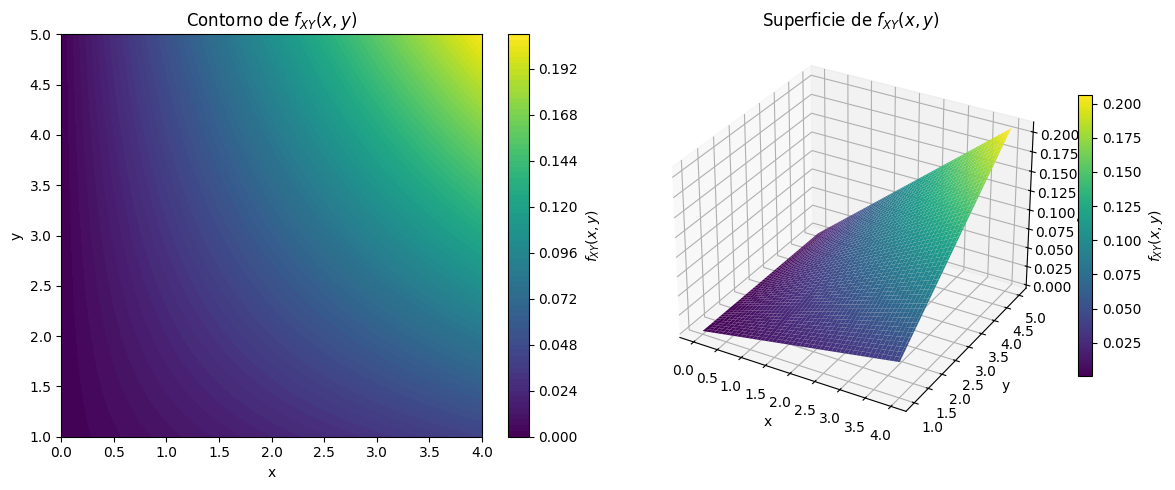

In [54]:
# Grafica de la función de densidad conjunta
x_vals = np.linspace(0, 4, 100)
y_vals = np.linspace(1, 5, 100)
X_grid, Y_grid = np.meshgrid(x_vals, y_vals)
Z_grid = f_xy_func(X_grid, Y_grid)

plt.figure(figsize=(12, 5))
ax1 = plt.subplot(1, 2, 1)
contour = ax1.contourf(X_grid, Y_grid, Z_grid, levels=80, cmap='viridis')
plt.colorbar(contour, ax=ax1, label=r'$f_{XY}(x, y)$')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title('Contorno de $f_{XY}(x, y)$')

ax2 = plt.subplot(1, 2, 2, projection='3d')
surf = ax2.plot_surface(X_grid, Y_grid, Z_grid, cmap='viridis', edgecolor='none')
plt.colorbar(surf, ax=ax2, shrink=0.7, label=r'$f_{XY}(x, y)$')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel(r'$f_{XY}(x, y)$')
ax2.set_title(r'Superficie de $f_{XY}(x, y)$')
plt.tight_layout()
plt.show()


In [55]:
# Grafica con plotly

# Gráfica 3D interactiva de fXY con mapa de color (Plotly)
fig_plotly = go.Figure(
	data=[
		go.Surface(
			x=X_grid,
			y=Y_grid,
			z=Z_grid,
			colorscale="Viridis",   # puedes cambiar a "Plasma", "Cividis", "Turbo", etc.
			colorbar=dict(title="fXY(x,y)"),
			contours={
				"z": {"show": True, "usecolormap": True, "highlightcolor": "white", "project_z": True}
			},
			hovertemplate="x=%{x:.2f}<br>y=%{y:.2f}<br>fXY=%{z:.2e}<extra></extra>"
		)
	]
)

fig_plotly.update_layout(
	title="Superficie 3D interactiva de fXY(x, y)",
	scene=dict(
		xaxis_title="x (psi)",
		yaxis_title="y (psi)",
		zaxis_title="fXY(x,y)"
	),
	width=900,
	height=700
)

fig_plotly.show(renderer="browser")

### **b**
Hallar $P(1 < X < 2, 2 < Y < 3)$.

In [56]:
# P(1 < X < 2, 2 < Y < 3) con c_val
x, y = sp.symbols('x y', real=True)
f_xy_b = c_val * x * y

# Integral doble en la región especificada
prob_b = sp.integrate(sp.integrate(f_xy_b, (y, 2, 3)), (x, 1, 2))
print(f'P(1 < X < 2, 2 < Y < 3) = {prob_b}')
print(f'P(1 < X < 2, 2 < Y < 3) = {float(prob_b)}')

P(1 < X < 2, 2 < Y < 3) = 5/128
P(1 < X < 2, 2 < Y < 3) = 0.0390625


### **c**
Hallar $P(X \geq 3, Y \leq 2)$.

In [57]:
# P(X ≥ 3, Y ≤ 2) con c_val
# La región es: 3 ≤ x ≤ 4, 1 ≤ y ≤ 2
x, y = sp.symbols('x y', real=True)
f_xy_c = c_val * x * y

# Integral doble en la región especificada
prob_c = sp.integrate(sp.integrate(f_xy_c, (y, 1, 2)), (x, 3, 4))
print(f'P(X ≥ 3, Y ≤ 2) = {prob_c}')
print(f'P(X ≥ 3, Y ≤ 2) = {float(prob_c)}')

P(X ≥ 3, Y ≤ 2) = 7/128
P(X ≥ 3, Y ≤ 2) = 0.0546875


### **d**
Hallar $P(X + Y < 3)$.

**Sln**

la region de interes correspondiente a los valores de $X + Y \le 3$ se puede comprobar que viene dado por:

$$
\mathcal{D} \equiv (0 \leq x \leq 2) \times (1 \leq y \leq 3-x)
$$

Asi:

$$
P(X + Y < 3) = \int_{\mathcal{D}} \frac{x y}{96} \, dy \, dx
$$

In [58]:
# definamos las regiones para resolver usando dblquad

reg1_x1 = 0
reg1_x2 = 2

reg1_down = lambda x: 1
reg1_up = lambda x: 3 - x


P_regg1, err_reg1 = dblquad(lambda y, x: f_xy_func(x, y), reg1_x1, reg1_x2, reg1_down, reg1_up)

print(f'P(1 < X < 2, 2 < Y < 3 - x) con dblquad = {P_regg1:.15f} +- {err_reg1:.2e}')

P(1 < X < 2, 2 < Y < 3 - x) con dblquad = 0.020833333333333 +- 2.31e-16


**R/=** la probabilidad tan baja de $\approx 2 \%$ concuerda con la region dibujada

## **Punto 8**

**Tiempo de telescopio.** 

Sean $X_1$, $X_2$ y $X_3$ el tiempo de telescopio (en minutos) solicitado por noche en 3 observatorios diferentes. Suponga que estas son variables aleatorias independientes y que siguen distribuciones normales con medias $\mu_1$, $\mu_2$ y $\mu_3$, y desviaciones estándar $\sigma_1$, $\sigma_2$ y $\sigma_3$, respectivamente.

### **a**
Si:
- $\mu_1 = \mu_2 = \mu_3 = 60$, 
- $\sigma_1^2 = \sigma_2^2 = \sigma_3^2 = 15$ 
- $T_0 = X_1 + X_2 + X_3$  

**Calcule** $P(T_0 \leq 200)$ y $P(150 \leq T_0 \leq 200)$.

In [59]:
# datos 
muT0 = 3*60    # minutos
sigmaT0 = 3*15     # minutos

fXY_T = lambda x: N(x, muT0, sigmaT0)


**Grafica de la funcion de densidad de $T_0$**

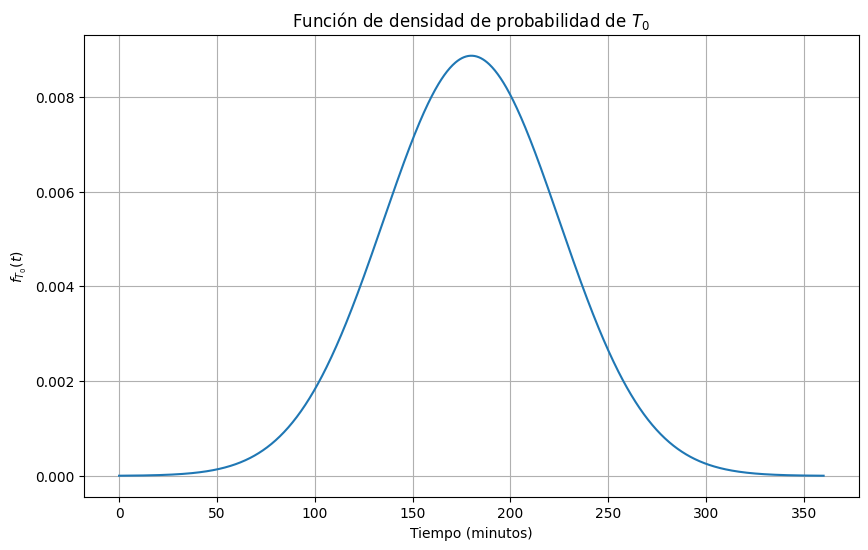

In [60]:
xsT0 = np.linspace(0, 2*180, 1000)

plt.figure(figsize=(10, 6))
plt.plot(xsT0, fXY_T(xsT0))
plt.xlabel('Tiempo (minutos)')  
plt.ylabel(r'$f_{T_0}(t)$')
plt.title(r'Función de densidad de probabilidad de $T_0$')
plt.grid()
plt.show()


**Cálculo de las probabilidades**

In [61]:
P_T0_le_200m = quad(fXY_T, 0, 200)[0]
P_T02 = quad(fXY_T, 150, 200)[0]

print(f'P(T0 <= 200 minutos) = {P_T0_le_200m:.4f}')
print(f'P(150 < T0 <= 200 minutos) = {P_T02:.4f}')


P(T0 <= 200 minutos) = 0.6716
P(150 < T0 <= 200 minutos) = 0.4191


### **b**
Usando los valores de $\mu_i$ y $\sigma_i$ en (a), calcule $P(\bar{X} \geq 55)$ y $P(58 \leq \bar{X} \leq 62)$.

**Sln**
Tomando $\bar{X} = \frac{T_o}{3}$ por el *T.L.C.* sabemos que $\bar{X} \sim N(x; \mu =  60, \sigma = \frac{15}{3} = 5)$ 

In [62]:
# definimos la fdp para el promedio de los tiempos de telescopio
nor_Xbar = lambda x: N(x, 60, 15/3)

Text(0.5, 1.0, 'Función de densidad de probabilidad de $\\bar{X}$')

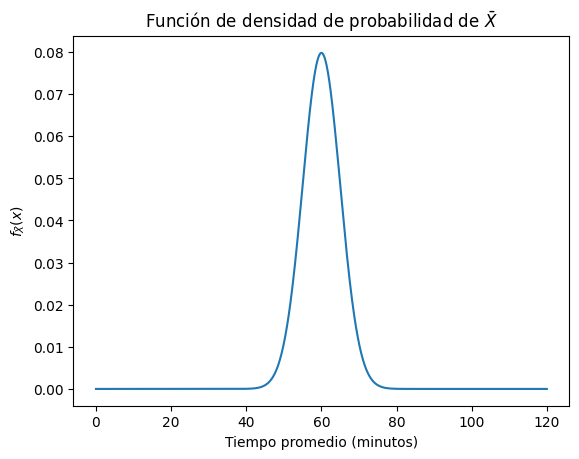

In [63]:
ts_promedio = np.linspace(0, 120, 1000)

plt.plot(ts_promedio, nor_Xbar(ts_promedio), label=r'$f_{\bar{X}}(x)$')
plt.xlabel('Tiempo promedio (minutos)')
plt.ylabel(r'$f_{\bar{X}}(x)$')
plt.title(r'Función de densidad de probabilidad de $\bar{X}$')

In [64]:
# calculamos P(X_bar <= 55) y P(58 > X_bar > 62)

p_Xbar_le_55 = quad(nor_Xbar, -np.inf, 55)[0]
p_Xbar_58_62 = quad(nor_Xbar, 58, 62)[0]

print(f'P(X_bar <= 55) = {p_Xbar_le_55:.4f}')
print(f'P(58 < X_bar <= 62) = {p_Xbar_58_62:.4f}')

P(X_bar <= 55) = 0.1587
P(58 < X_bar <= 62) = 0.3108


### **c**
Usando los valores de $\mu_i$ y $\sigma_i$ en (a), calcule e interprete $P(-10 \leq X_1 - 0.5X_2 - 0.5X_3 \leq 5)$.

In [65]:
# Sea R = x_1 - 0.5X_2 - 0.5X_3

mu_R = 60 - 0.5*60 - 0.5*60
sigma_R = np.sqrt(15**2 + (0.5*15)**2 + (0.5*15)**2)

# Curva normal de R
nor_R = lambda r: N(r, mu_R, sigma_R)

print(f'La media de R es: {mu_R:.4f}')
print(f'La desviación estándar de R es: {sigma_R:.4f}')

La media de R es: 0.0000
La desviación estándar de R es: 18.3712


In [66]:
# Calculemos la probabilidad solicitada

p_R_le_0, err = quad(nor_R, -10, 5)

print(f'P(-10 <= R <= 5) = {p_R_le_0:.4f} +- {err:.2e}')

P(-10 <= R <= 5) = 0.3141 +- 3.49e-15


### **d**
Si $\mu_1 = 40$, $\mu_2 = 50$, $\mu_3 = 60$, $\sigma_1^2 = 10$, $\sigma_2^2 = 12$ y $\sigma_3^2 = 14$, calcule $P(X_1 + X_2 + X_3 \leq 160)$ y $P(X_1 + X_2 \geq 2X_3)$.

In [67]:
mu_1 = 40 
mu_2 = 50
mu_3 = 60 
sigma_1 = 5
sigma_2 = 10
sigma_3 = 15

mu_sum = mu_1 + mu_2 + mu_3
sigma_sum = np.sqrt(sigma_1**2 + sigma_2**2 + sigma_3**2)

In [68]:
nor_sum = lambda x: N(x, mu_sum, sigma_sum)

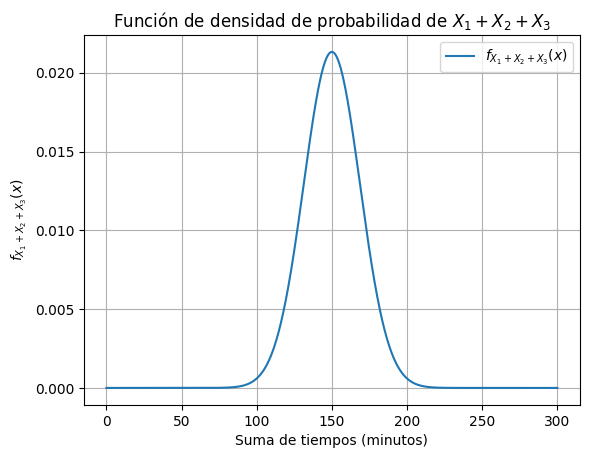

In [69]:
xs_sum = np.linspace(0, 300, 1000)
plt.plot(xs_sum, nor_sum(xs_sum), label=r'$f_{X_1 + X_2 + X_3}(x)$')
plt.xlabel('Suma de tiempos (minutos)')
plt.ylabel(r'$f_{X_1 + X_2 + X_3}(x)$')
plt.title(r'Función de densidad de probabilidad de $X_1 + X_2 + X_3$')
plt.legend()
plt.grid()
plt.show()

In [70]:
# probabilidades solicitadas 
psum_le_160, err160 = quad(nor_sum, -np.inf, 160)

print(f'P(X_1 + X_2 + X_3 <= 160) = {psum_le_160:.4f} +- {err160:.2e}')

P(X_1 + X_2 + X_3 <= 160) = 0.7035 +- 8.73e-10


## **Punto 9**

**Halo de galaxias.**

Suponga que el tamaño esperado del halo de galaxias espirales **tipo-a (Sa)** es **105 kly (kilo años luz)** y su desviación estándar es **8 kly**. Para una **tipo-b (Sb)**, suponga un tamaño esperado del halo y una desviación estándar de **100 kly** y **6 kly**, respectivamente.

Sea $\bar{X}$ el valor medio muestral del tamaño del halo en una muestra aleatoria de **40 galaxias Sa**, y sea $\bar{Y}$ lo mismo pero para **35 galaxias Sb**.

### **a)**
¿A qué distribución se aproximan $\bar{X}$ y $\bar{Y}$?

**Respuesta**
Sin importar las funciones de distribución de densidad de $X$ y $Y$, $\bar{X}$ y $\bar{Y}$ (Por *T.L.C.*) se aproximan a una distribución Normal de forma que:

$$
\bar{X} \sim N(x; \mu = 105 \, \text{kly}, \sigma^2 = \frac{8^2}{40}) \quad \wedge \quad \bar{Y} \sim N(y; \mu = 100 \, \text{kly}, \sigma^2 = \frac{6^2}{35})
$$

In [71]:
# Definimos las distribuciones que siguen los promedios de las muestras de tamaños de cada tipo de estrella
# Para las tipo Sa
muXprom = 105  # kly
sigmaXprom = np.sqrt(8/40)

xs2 = np.linspace(102, 108, 1000)
nor_Xprom = lambda x: N(x, muXprom, sigmaXprom)

print(f'La media de X_promedio para tipo Sa es: {muXprom:.4f}')
print(f'La desviación estándar de X_promedio para tipo Sa es: {sigmaXprom:.4f}')


La media de X_promedio para tipo Sa es: 105.0000
La desviación estándar de X_promedio para tipo Sa es: 0.4472


In [72]:
# Para las tipo Sb
muYprom = 100  # kly
sigmaYprom = np.sqrt(6/35)

ys2 = np.linspace(98, 102, 1000)
nor_Yprom = lambda y: N(y, muYprom, sigmaYprom)

print(f'La media de Y_promedio para tipo Sb es: {muYprom:.4f}')
print(f'La desviación estándar de Y_promedio para tipo Sb es: {sigmaYprom:.4f}')

La media de Y_promedio para tipo Sb es: 100.0000
La desviación estándar de Y_promedio para tipo Sb es: 0.4140


**Gráfica**

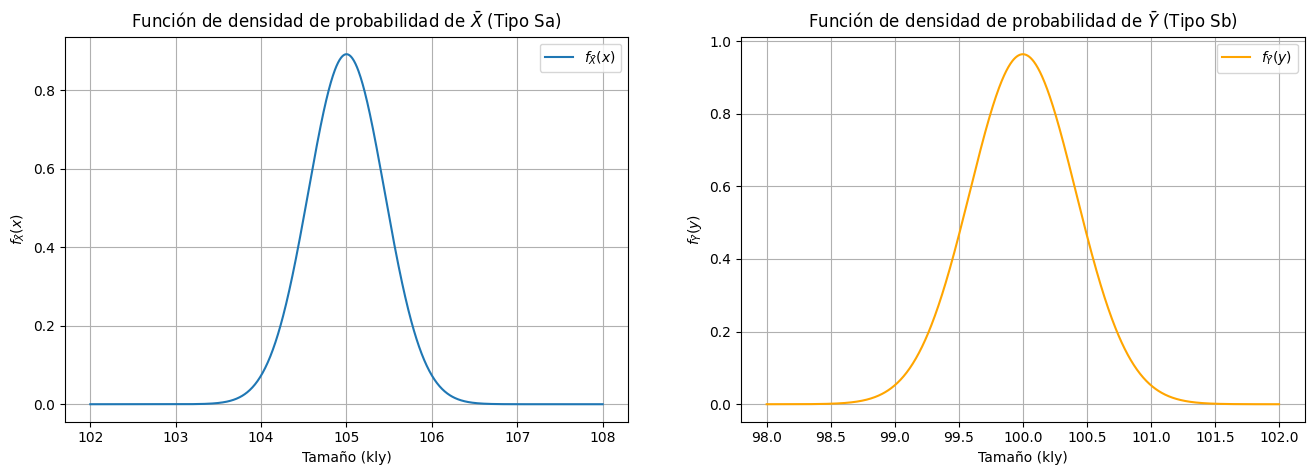

In [73]:
fig2, ax2 = plt.subplots(1, 2, figsize=(16, 5))

ax2[0].plot(xs2, nor_Xprom(xs2), label=r'$f_{\bar{X}}(x)$')
ax2[0].set_xlabel('Tamaño (kly)')
ax2[0].set_ylabel(r'$f_{\bar{X}}(x)$')
ax2[0].set_title(r'Función de densidad de probabilidad de $\bar{X}$ (Tipo Sa)')
ax2[0].legend()
ax2[0].grid()

ax2[1].plot(ys2, nor_Yprom(ys2), label=r'$f_{\bar{Y}}(y)$', color='orange')
ax2[1].set_xlabel('Tamaño (kly)')
ax2[1].set_ylabel(r'$f_{\bar{Y}}(y)$')
ax2[1].set_title(r'Función de densidad de probabilidad de $\bar{Y}$ (Tipo Sb)')
ax2[1].legend()
ax2[1].grid()

plt.show()


### **b)**
¿A qué distribución se aproxima $\bar{X} - \bar{Y}$?

**Respuesta** Como ambas siguen una distribución lineal, la diferencia $\bar{X} - \bar{Y}$ seguira a su vez una distrbución normal.

In [74]:
# Se define la distribucion de la diferencia de los promedios

mu_diff = muXprom - muYprom
sigma_diff = np.sqrt(sigmaXprom**2 + sigmaYprom**2)

xs_diff = np.linspace(0, 10, 1000)
nor_diff = lambda d: N(d, mu_diff, sigma_diff)

print(f'La media de la diferencia de promedios es: {mu_diff:.4f}')
print(f'La desviación estándar de la diferencia de promedios es: {sigma_diff:.4f}')

La media de la diferencia de promedios es: 5.0000
La desviación estándar de la diferencia de promedios es: 0.6094


**Grafica**

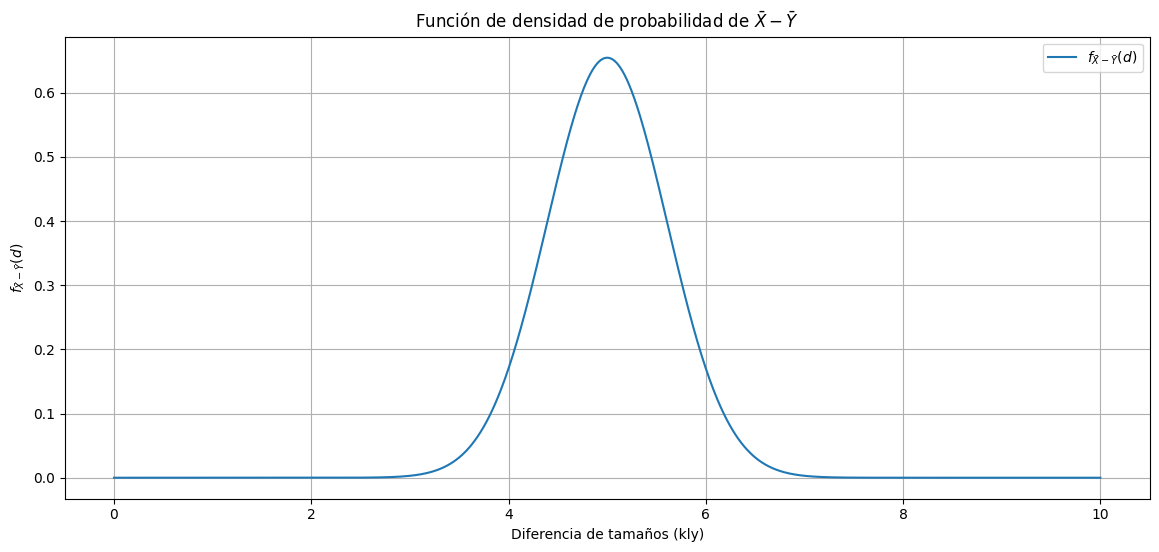

In [75]:
plt.figure(figsize=(14, 6))
plt.plot(xs_diff, nor_diff(xs_diff), label=r'$f_{\bar{X} - \bar{Y}}(d)$')
plt.xlabel('Diferencia de tamaños (kly)')
plt.ylabel(r'$f_{\bar{X} - \bar{Y}}(d)$')
plt.title(r'Función de densidad de probabilidad de $\bar{X} - \bar{Y}$')
plt.legend()
plt.grid()
plt.show()


### **c)**
Calcule (aproximadamente) $P(-1 \leq \bar{X} - \bar{Y} \leq 1)$.

In [76]:
# calculo de la probabilidad usando la distribucion de la diferencia de los promedios
p_diff_le_5, err_diff = quad(nor_diff, -1, 1)

print(f'P(-1 <= X_promedio - Y_promedio <= 1) = {p_diff_le_5} +- {err_diff:.2e}')

P(-1 <= X_promedio - Y_promedio <= 1) = 2.6314687576526284e-11 +- 2.81e-19


### **d)**
Calcule $P(\bar{X} - \bar{Y} \geq 10)$. Si observa que $\bar{X} - \bar{Y} \geq 10$, ¿dudaría de que $\mu_1 - \mu_2 = 5$?

In [77]:
P_diff_gre_10_alt = 1 - quad(lambda d: N(d, mu_diff, sigma_diff), -np.inf, 10 )[0]

print(f'P(X_promedio - Y_promedio > 10) = {P_diff_gre_10_alt}')

P(X_promedio - Y_promedio > 10) = 0.0
